In [1]:
import os
from IPython.display import display
from ipywidgets import widgets, VBox
from PIL import Image
import matplotlib.pyplot as plt

# === CONFIG ===
image_folder = "/home/bjangley/VPR/mapillary_utils/spanish_steps"
image_extensions = (".jpg", ".jpeg", ".png")

# === GET ALL IMAGE PATHS ===
image_files = sorted([
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.lower().endswith(image_extensions)
])

# === TEXT BOX TO DISPLAY FILENAME ===
filename_text = widgets.Text(
    value='',
    description='Filename:',
    disabled=False,
    layout=widgets.Layout(width='100%')
)

# === IMAGE VIEWER FUNCTION ===
def show_image(idx):
    image_path = image_files[idx]
    img = Image.open(image_path)

    # Update filename textbox
    filename_text.value = os.path.basename(image_path)

    # Show image
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{filename_text.value} ({idx+1}/{len(image_files)})", fontsize=12)
    plt.show()

# === SLIDER ===
slider = widgets.IntSlider(min=0, max=len(image_files)-1, step=1, description='Image:')

# === DISPLAY INTERFACE ===
ui = VBox([slider, filename_text])
widgets.interact(show_image, idx=slider)
display(ui)


interactive(children=(IntSlider(value=0, description='Image:', max=311), Output()), _dom_classes=('widget-inte…

In [2]:
import os
import pandas as pd

# === CONFIG ===
image_folder = "/home/bjangley/VPR/mapillary_utils/spanish_steps"
metadata_path = "/home/bjangley/VPR/mapillary_utils/spanish_steps/metadata.csv"
image_extensions = (".jpg", ".jpeg", ".png")

# === Load metadata ===
df = pd.read_csv(metadata_path)

# === Get image names (without extension) as strings ===
existing_images = {
    os.path.splitext(f)[0]
    for f in os.listdir(image_folder)
    if f.lower().endswith(image_extensions)
}

# === Filter metadata to only include images present in folder ===
df_filtered = df[df['id'].astype(str).isin(existing_images)]

# === Count number of images per sequence ===
sequence_counts = df_filtered['sequence'].value_counts()

# === Display top N sequences ===
top_n = 5
print(f"Top {top_n} sequences with most images:")
print(sequence_counts.head(top_n))


Top 5 sequences with most images:
sequence
S0kbYi8VQ_WxGBZSOrY3Wg    106
dr0WgyAvIi2geL_9D7JMjA     57
8YkP2nVvfrlIlRvsfwop8A     38
vG1rSPuEQFmhYYoq4sHX8w     22
eiaVWKxDs9Ty70Qh2SOIv3     19
Name: count, dtype: int64



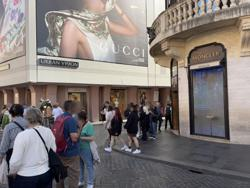
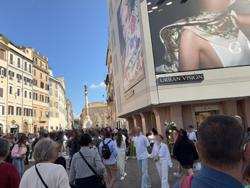
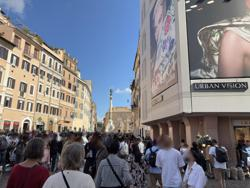
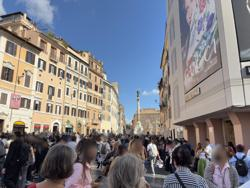
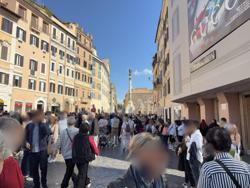
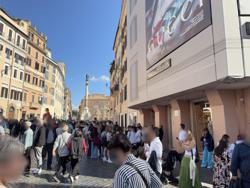
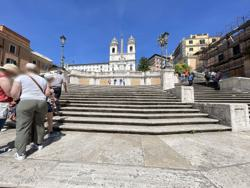
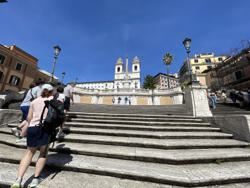
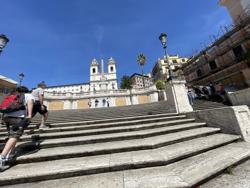
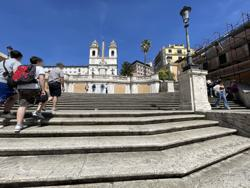
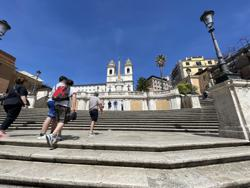
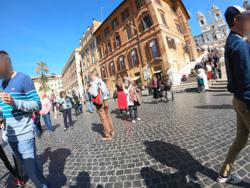
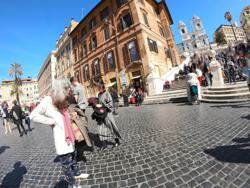
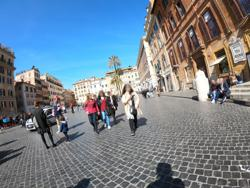
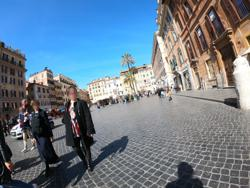
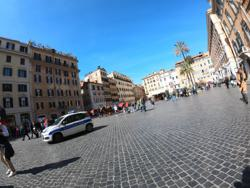
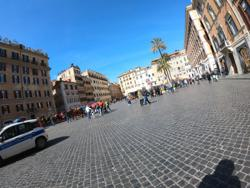
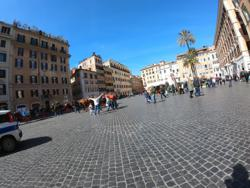
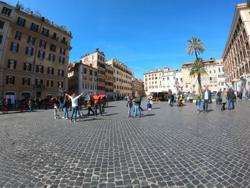
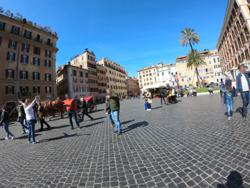
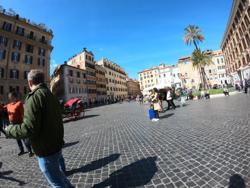
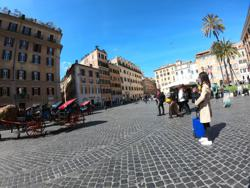
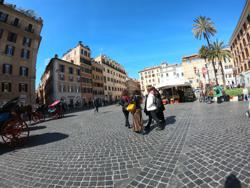
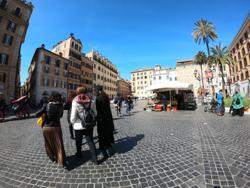
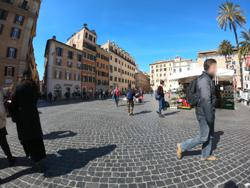
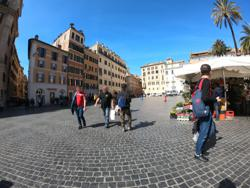
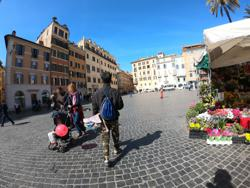
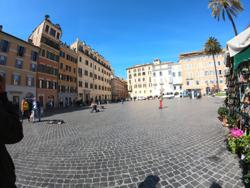
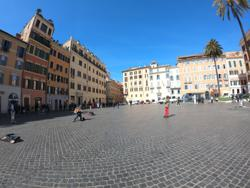
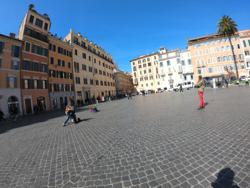
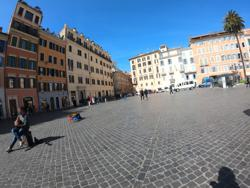
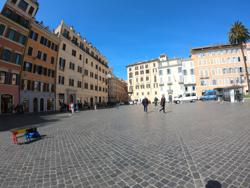
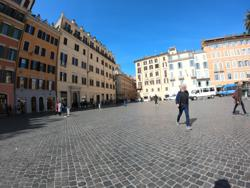
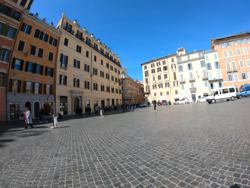
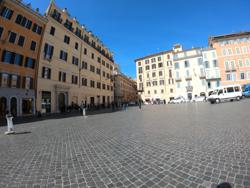
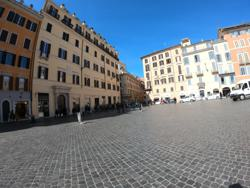
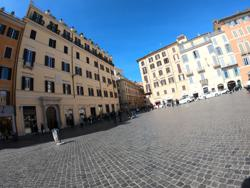
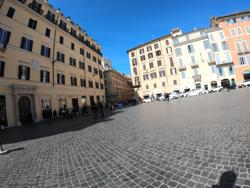
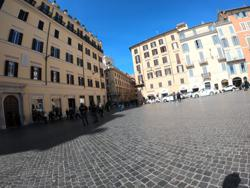
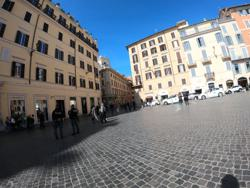
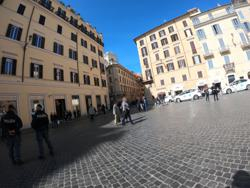
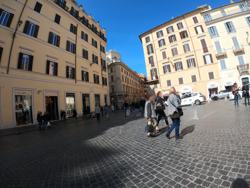
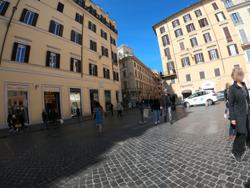
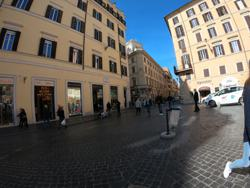
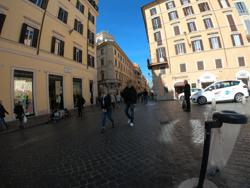
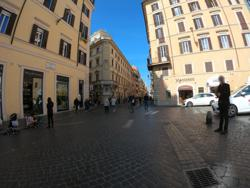
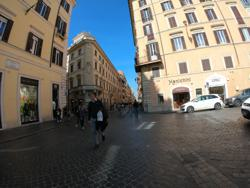
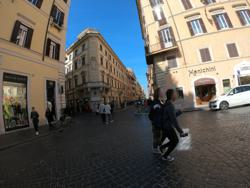
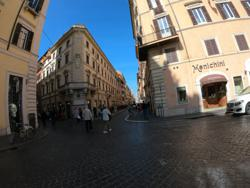
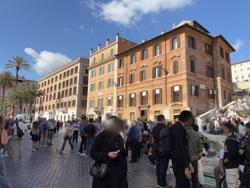
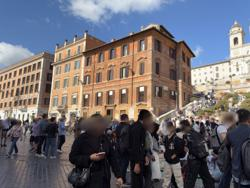
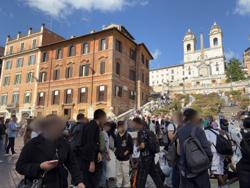
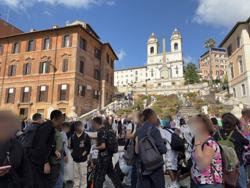
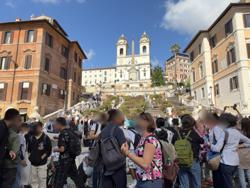
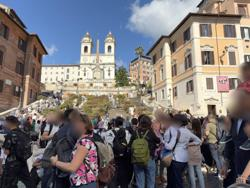
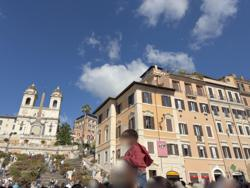
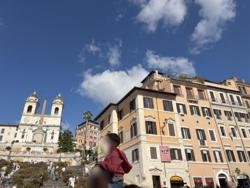
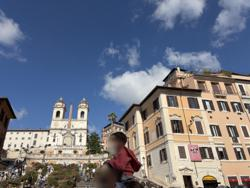
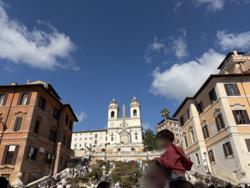
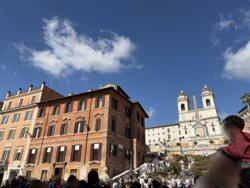
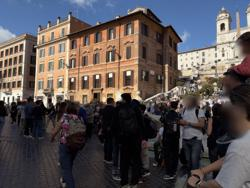
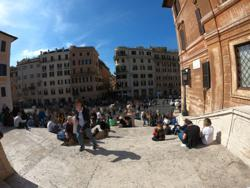
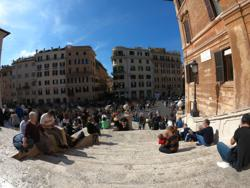
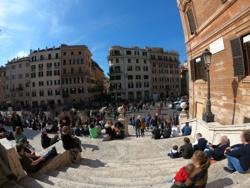
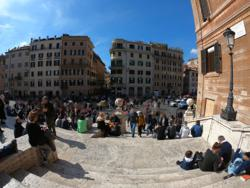
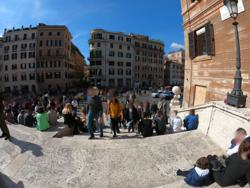
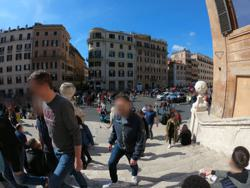
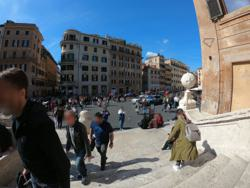
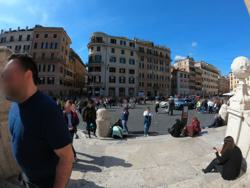
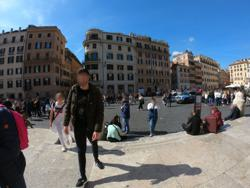
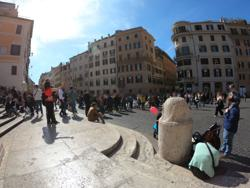
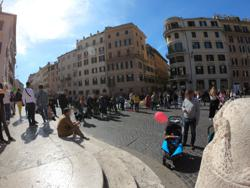
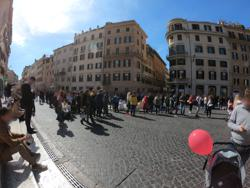
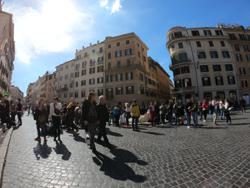
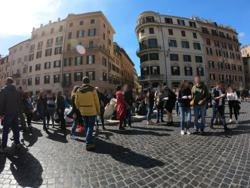
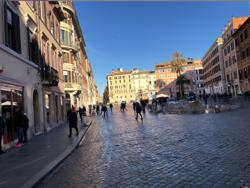
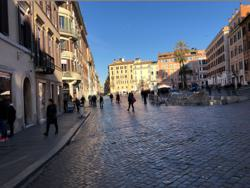
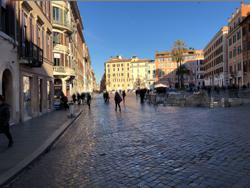
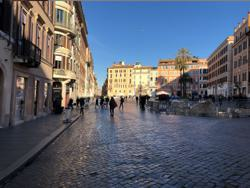
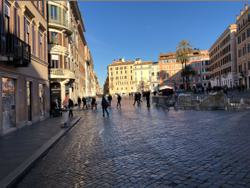
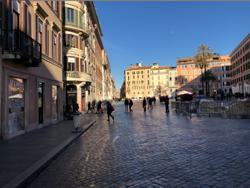
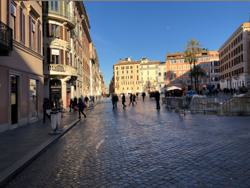
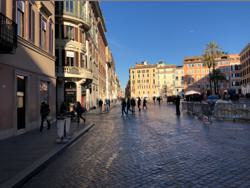
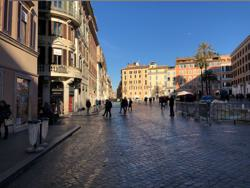
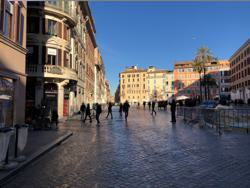
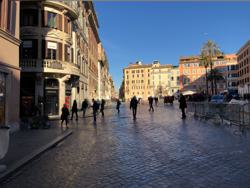
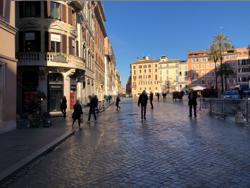
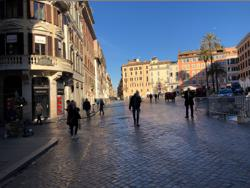
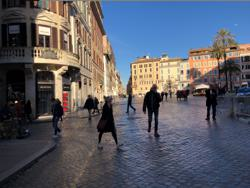
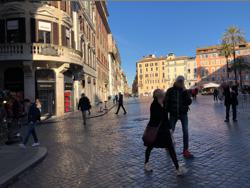
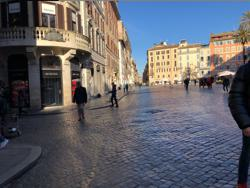
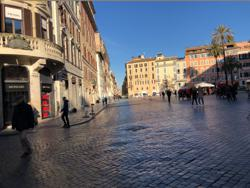
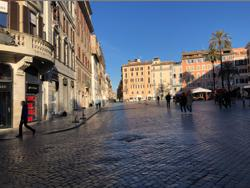
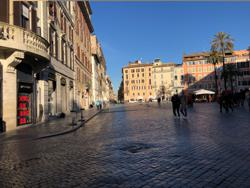
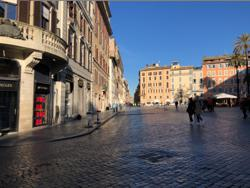
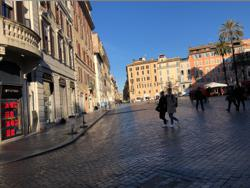
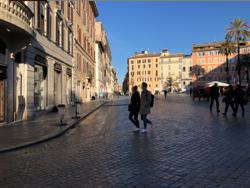
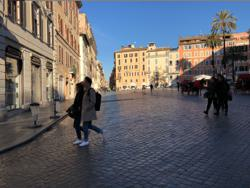
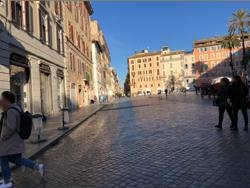
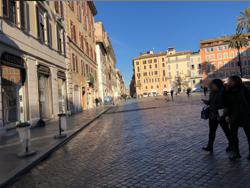
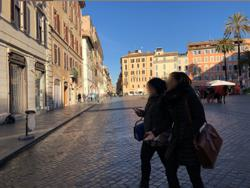
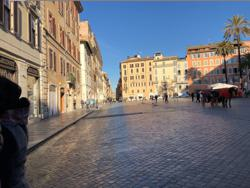
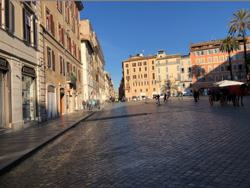
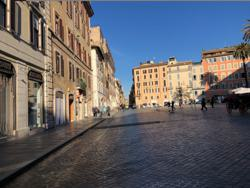
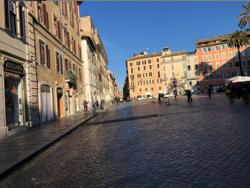
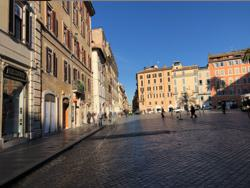
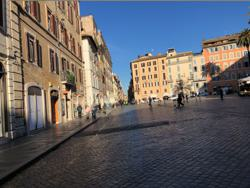
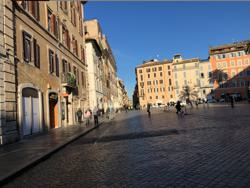
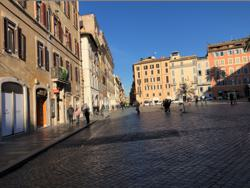
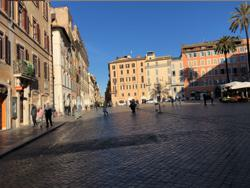
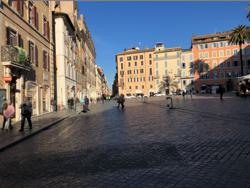
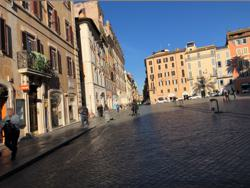
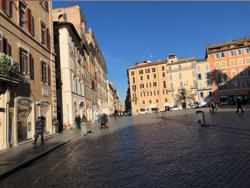
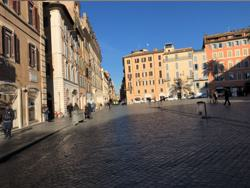
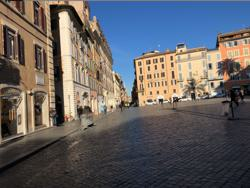
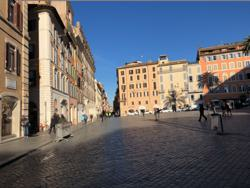
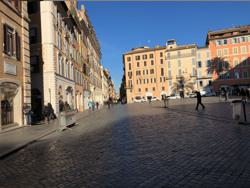
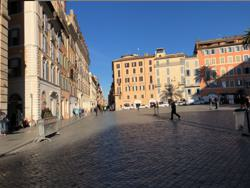
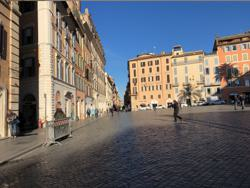
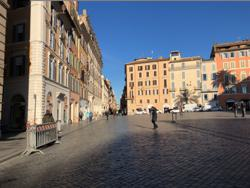
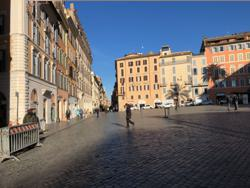
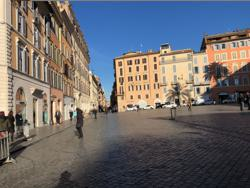
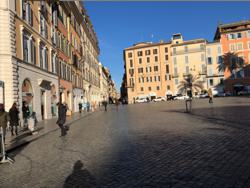
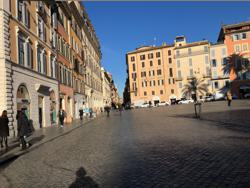
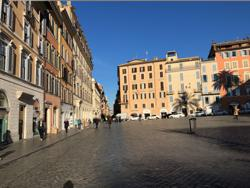
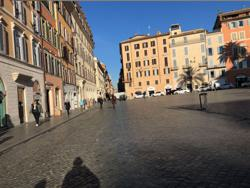
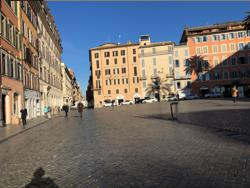
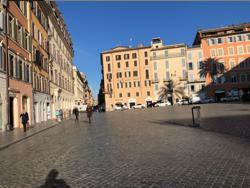
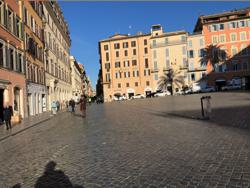
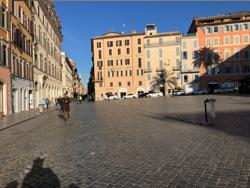
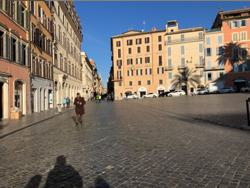
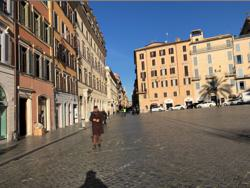
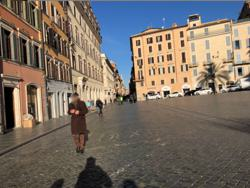
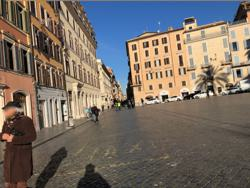
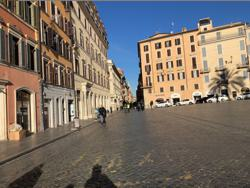
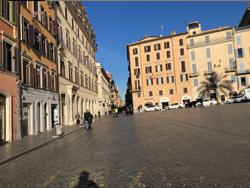
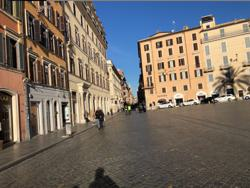
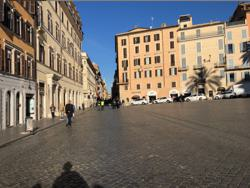
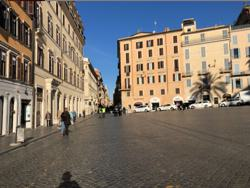
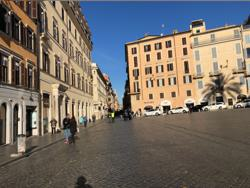
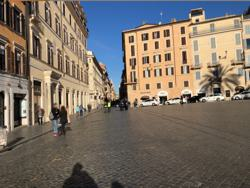
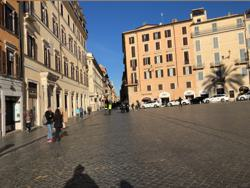
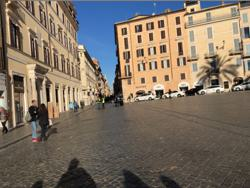
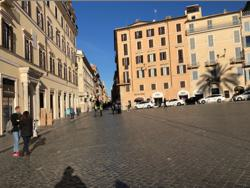
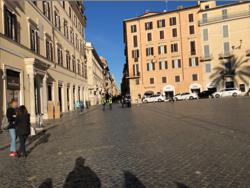
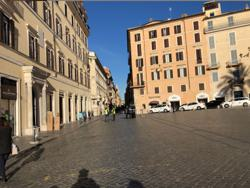
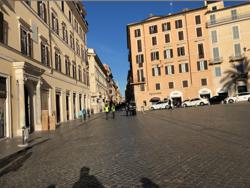
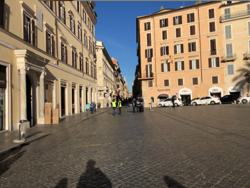
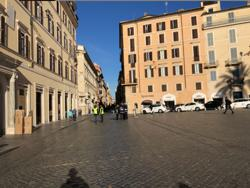
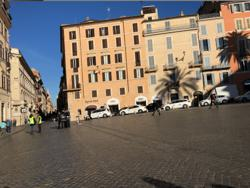
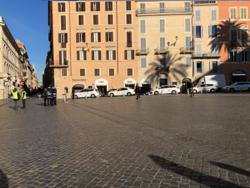
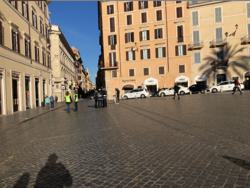
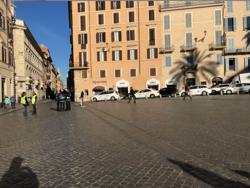
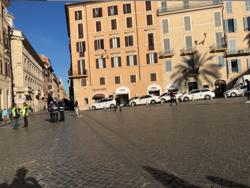
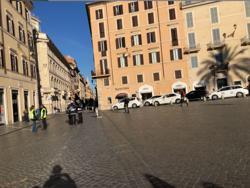
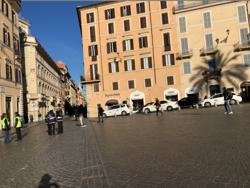
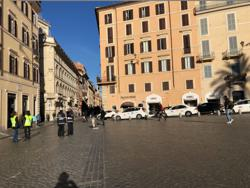
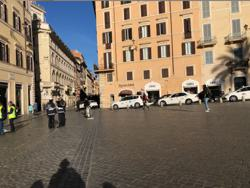
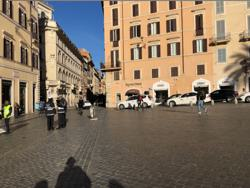
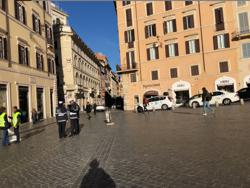
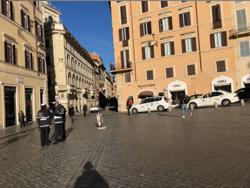
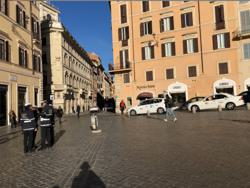
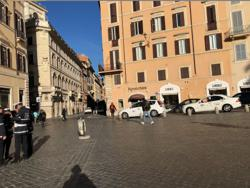
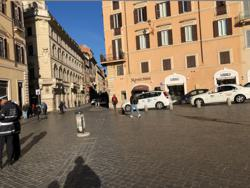
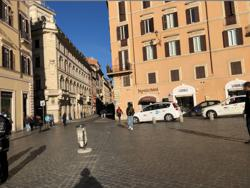
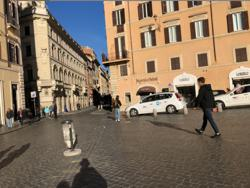
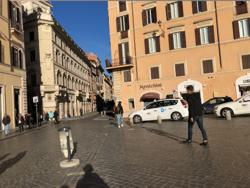
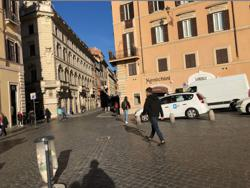
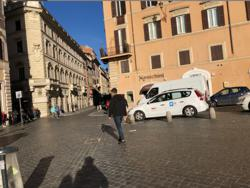
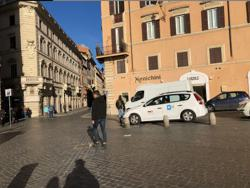
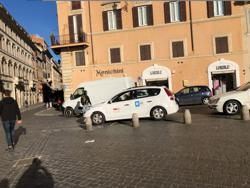
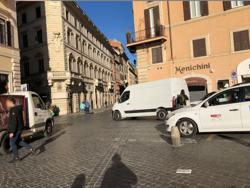
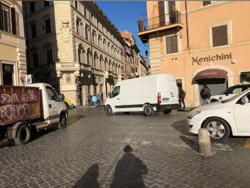
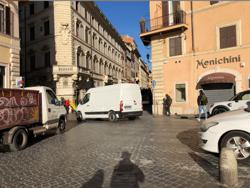
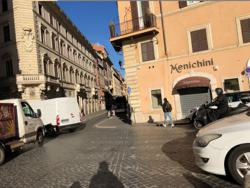
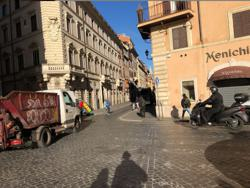
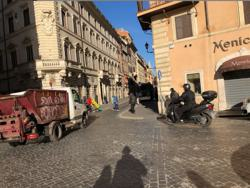
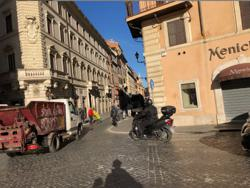
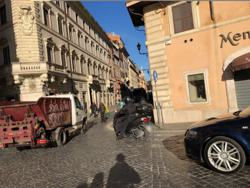
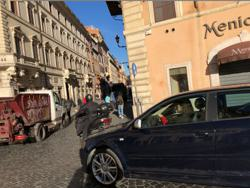
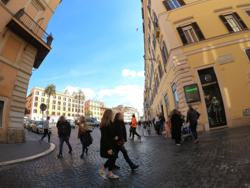
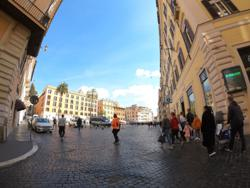
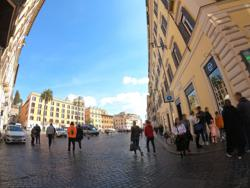
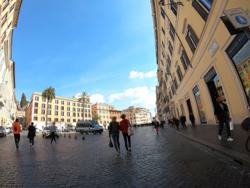
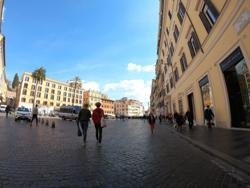
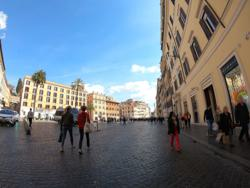
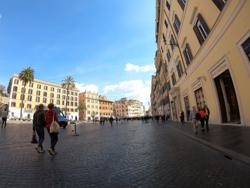
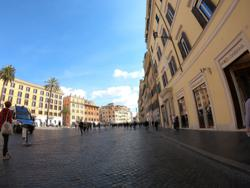
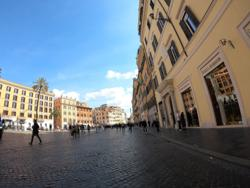
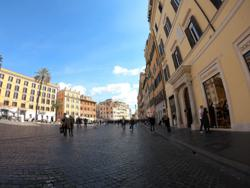
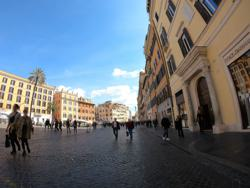
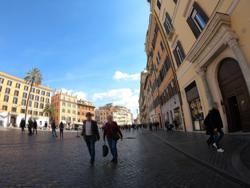
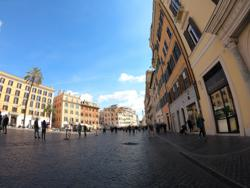
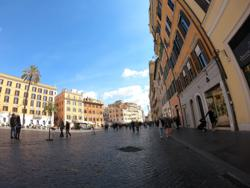
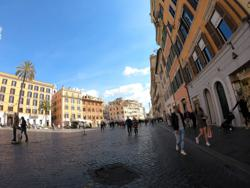
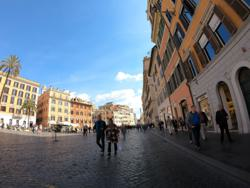
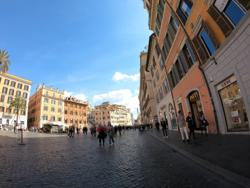
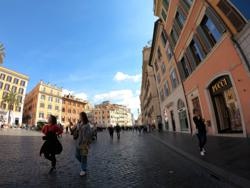
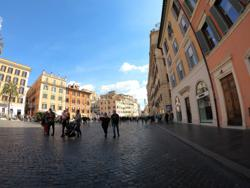
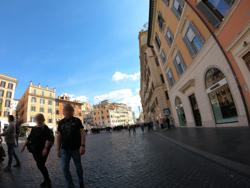
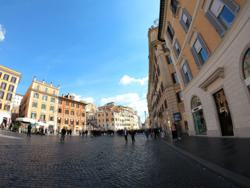
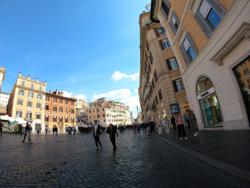
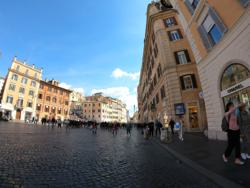
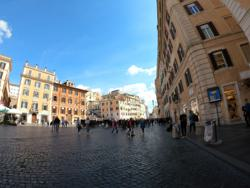
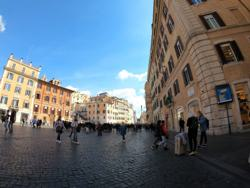
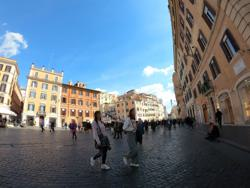
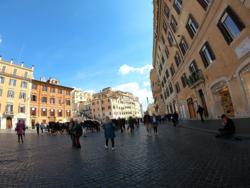
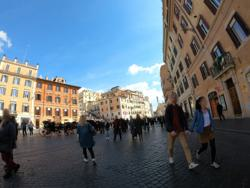
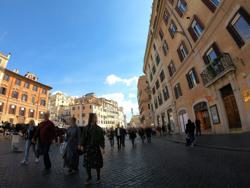
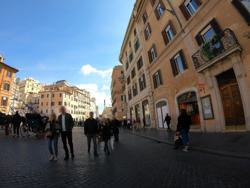
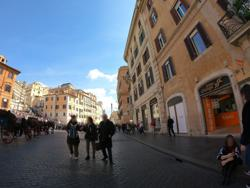
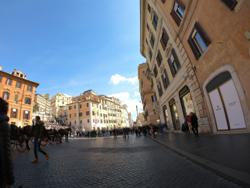
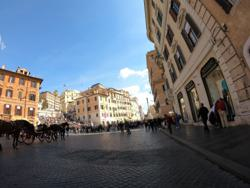
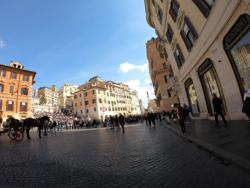
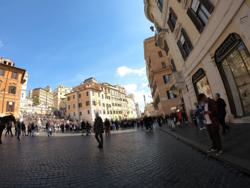
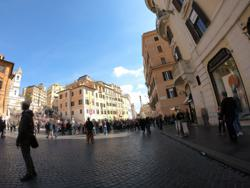
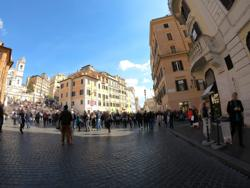
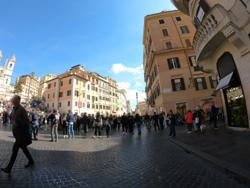
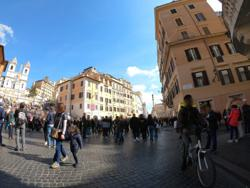
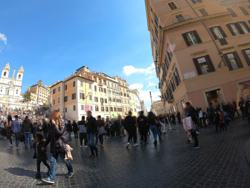
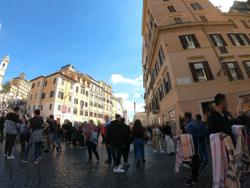
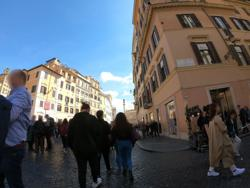
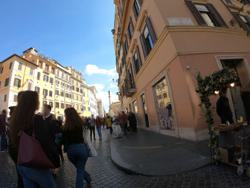
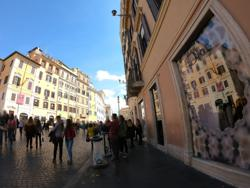
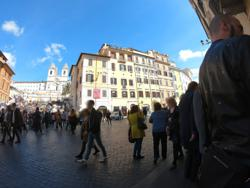
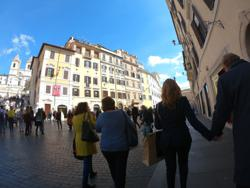
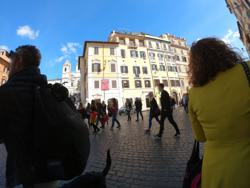
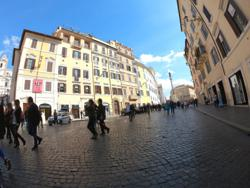
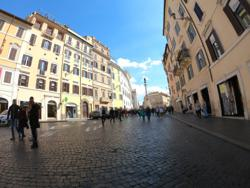
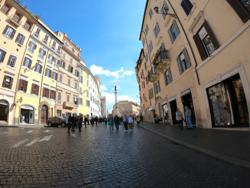
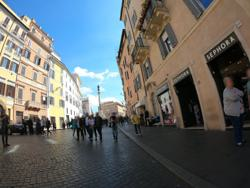
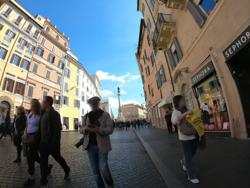
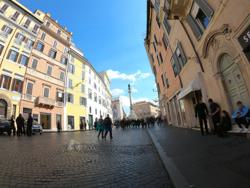
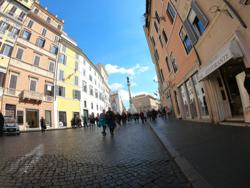
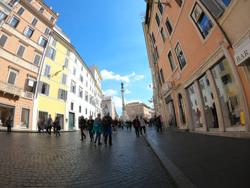
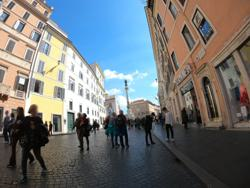
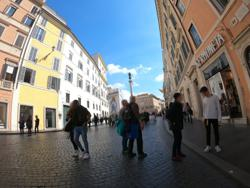
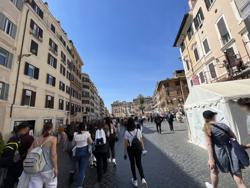
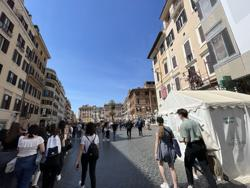
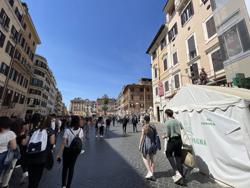
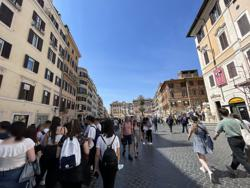
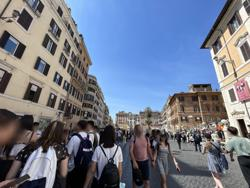
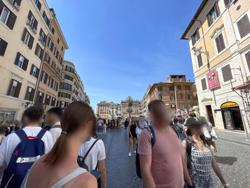
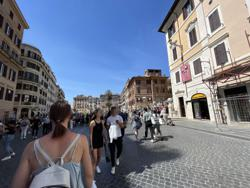
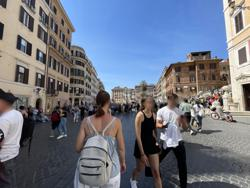
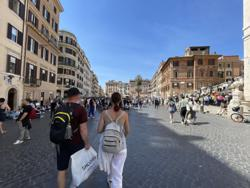
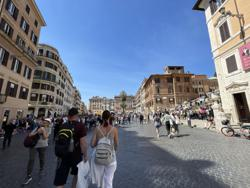
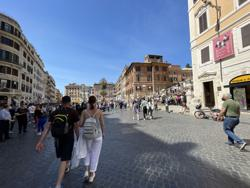
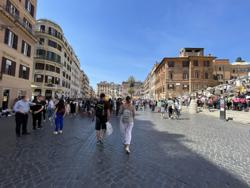
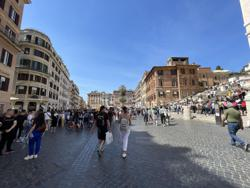
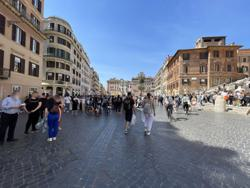
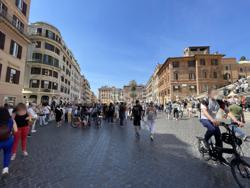
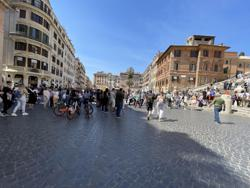
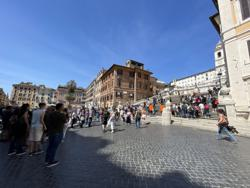
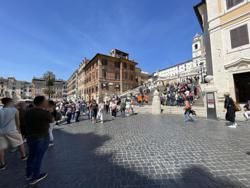
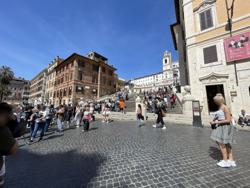
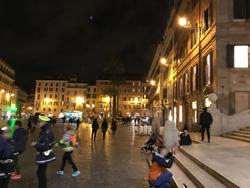
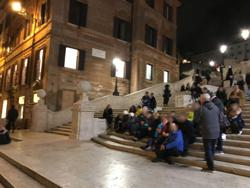
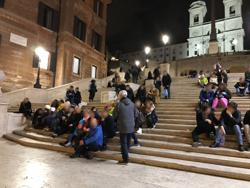
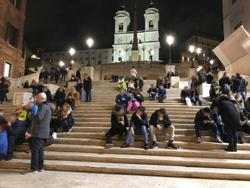
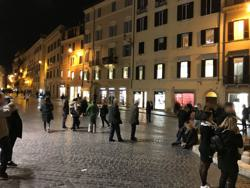
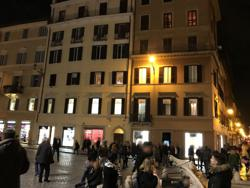
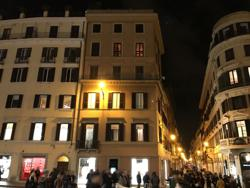
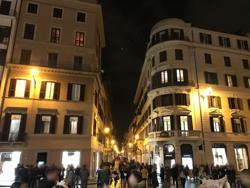
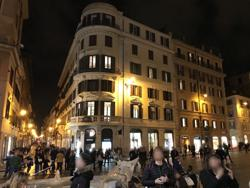
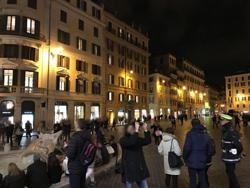
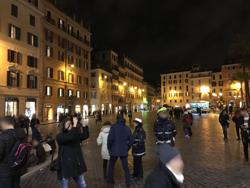
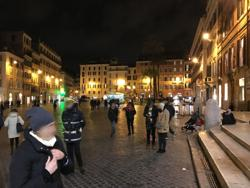
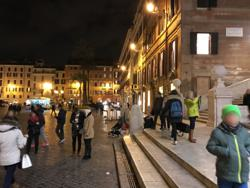
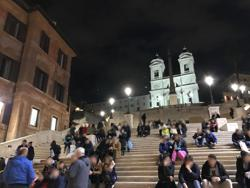
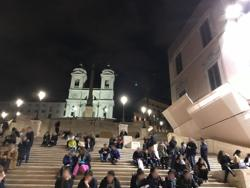
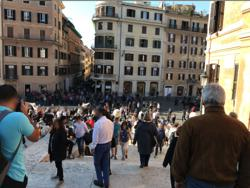
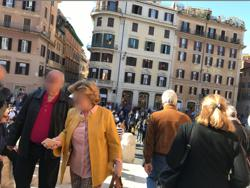
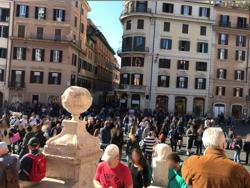
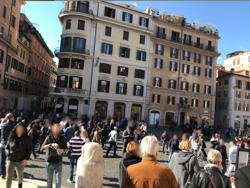
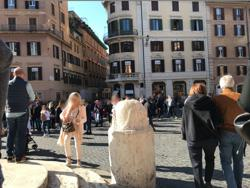
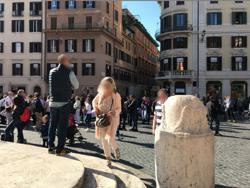
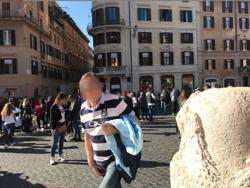
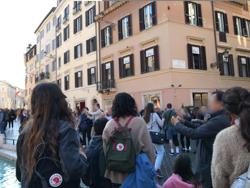
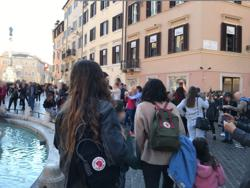
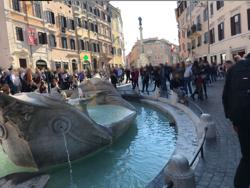
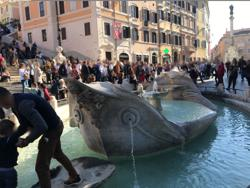
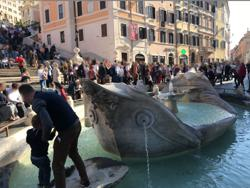
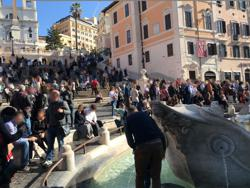
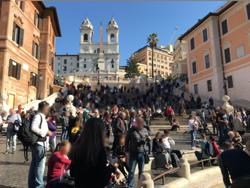
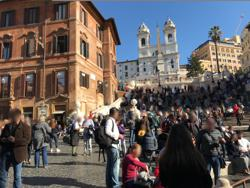
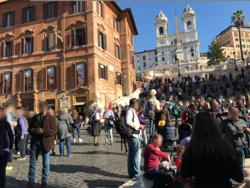
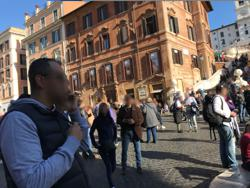
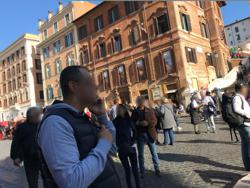
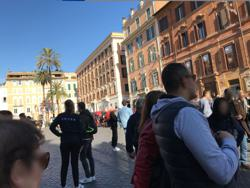
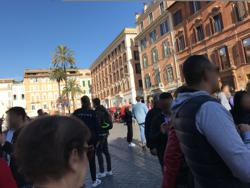
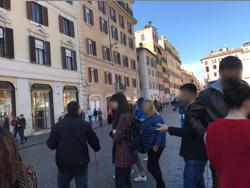
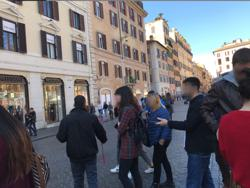

In [5]:
import os
import pandas as pd
import folium
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import base64

# === CONFIG ===
image_folder = "/home/bjangley/VPR/mapillary_utils/spanish_steps"
metadata_path = "/home/bjangley/VPR/mapillary_utils/spanish_steps/metadata.csv"
image_extensions = (".jpg", ".jpeg", ".png")
tile_url = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'

# === Load metadata ===
df = pd.read_csv(metadata_path)

# === Get valid image IDs in folder ===
existing_ids = {
    os.path.splitext(f)[0]
    for f in os.listdir(image_folder)
    if f.lower().endswith(image_extensions)
}

# === Filter metadata to only include existing images ===
df['id_str'] = df['id'].astype(str)
df_filtered = df[df['id_str'].isin(existing_ids)].copy()
df_filtered = df_filtered.sort_values(by=['sequence', 'captured_at'])

# === Find top 5 sequences with most images present ===
top_sequences = (
    df_filtered['sequence']
    .value_counts()
    .head(10)
    .index
    .tolist()
)
df_filtered = df_filtered[df_filtered['sequence'].isin(top_sequences)]

# === Generate unique colors for each sequence ===
sequences = df_filtered['sequence'].unique()
color_map = {
    seq: '#{:02x}{:02x}{:02x}'.format(*[int(c*255) for c in plt.cm.tab20(i % 20)[:3]])
    for i, seq in enumerate(sequences)
}

# === Initialize map ===
center = [df_filtered['lat'].mean(), df_filtered['long'].mean()]
m = folium.Map(location=center, zoom_start=17, tiles=None)
folium.TileLayer(tiles=tile_url, attr='Esri Satellite').add_to(m)

# === Add FeatureGroups for layer control ===
for seq in sequences:
    group = df_filtered[df_filtered['sequence'] == seq].sort_values(by='captured_at')
    color = color_map[seq]
    fg = folium.FeatureGroup(name=f"Sequence {seq[:8]}", show=True)

    # Polylines (GPS)
    gps_coords = list(zip(group['lat'], group['long']))
    if len(gps_coords) >= 2:
        folium.PolyLine(gps_coords, color=color, weight=4, tooltip=f"Sequence: {seq[:8]}").add_to(fg)

    # Add markers with image preview
    for _, row in group.iterrows():
        image_path = os.path.join(image_folder, f"{row['id_str']}.jpg")
        try:
            with Image.open(image_path) as img:
                img.thumbnail((250, 250))
                buffered = BytesIO()
                img.save(buffered, format="JPEG")
                img_b64 = base64.b64encode(buffered.getvalue()).decode()
                img_html = f'<img src="data:image/jpeg;base64,{img_b64}" width="250"><br><b>ID:</b> {row["id_str"]}'
        except:
            img_html = f"<b>Image not found:</b> {row['id_str']}"

        folium.Marker(
            location=[row['lat'], row['long']],
            popup=folium.Popup(html=img_html, max_width=300),
            icon=folium.Icon(color='blue', icon='camera', prefix='fa')
        ).add_to(fg)

    fg.add_to(m)

# === Add LayerControl ===
folium.LayerControl().add_to(m)

# === Simple Legend HTML ===
legend_html = '''
<div style="position: fixed; bottom: 20px; left: 20px; width: 250px; height: auto; background-color: white;
     z-index:9999; padding: 10px; font-size: 12px; border: 1px solid grey;">
<b>Legend:</b><br>
<span style="display:inline-block;width:12px;height:4px;background-color:black;margin-right:5px;"></span> Solid line = GPS sequence<br>
<span style="display:inline-block;width:12px;height:12px;background-color:blue;margin-right:5px;border-radius:50%;"></span> Marker = Image location<br>
Click on marker to view image.
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# === Show map ===
m


In [4]:
import os
import pandas as pd
from PIL import Image
from io import BytesIO
import base64
import ipywidgets as widgets
from IPython.display import display, HTML
from datetime import datetime

# === CONFIG ===
image_folder = "/home/bjangley/VPR/mapillary_utils/spanish_steps"
metadata_path = "/home/bjangley/VPR/mapillary_utils/spanish_steps/metadata.csv"
image_extensions = (".jpg", ".jpeg", ".png")

# === Load metadata ===
df = pd.read_csv(metadata_path)

# === Get existing image IDs in folder ===
existing_ids = {
    os.path.splitext(f)[0]
    for f in os.listdir(image_folder)
    if f.lower().endswith(image_extensions)
}

# === Filter to images that exist in the folder ===
df['id_str'] = df['id'].astype(str)
df = df[df['id_str'].isin(existing_ids)].copy()

# === Parse 'captured_at' as datetime ===
df['captured_at_dt'] = pd.to_datetime(df['captured_at'], errors='coerce')

# === Define night time filter (e.g., 20:00 to 06:00) ===
def is_night(dt):
    if pd.isna(dt):
        return False
    hour = dt.hour
    return hour >= 20 or hour < 6

df_night = df[df['captured_at_dt'].apply(is_night)].reset_index(drop=True)

# === Widget function to display image + metadata ===
def show_night_image(idx):
    row = df_night.iloc[idx]
    image_path = os.path.join(image_folder, f"{row['id_str']}.jpg")

    # Load image preview
    try:
        with Image.open(image_path) as img:
            img.thumbnail((400, 400))
            buffered = BytesIO()
            img.save(buffered, format="JPEG")
            img_b64 = base64.b64encode(buffered.getvalue()).decode()
            img_html = f'<img src="data:image/jpeg;base64,{img_b64}" width="400">'
    except:
        img_html = "<b>Image not found or unreadable.</b>"

    meta_html = f"""
    <b>Image ID:</b> {row['id_str']}<br>
    <b>Sequence:</b> {row['sequence']}<br>
    <b>Captured At:</b> {row['captured_at_dt']}<br>
    <b>Latitude:</b> {row['lat']}<br>
    <b>Longitude:</b> {row['long']}
    """

    display(HTML(f"{img_html}<br><br>{meta_html}"))

# === Display slider + viewer ===
slider = widgets.IntSlider(min=0, max=len(df_night)-1, step=1, description='Night Img:')
widgets.interact(show_night_image, idx=slider)


interactive(children=(IntSlider(value=0, description='Night Img:', max=310), Output()), _dom_classes=('widget-…

<function __main__.show_night_image(idx)>

In [1]:
import os
import pandas as pd
from PIL import Image
from io import BytesIO
import base64
import ipywidgets as widgets
from IPython.display import display, HTML

# === CONFIG ===
sequence_id = "n4k0JDQfdeItNMf9OOwCUQ"
image_folder = "/home/bjangley/VPR/mapillary_utils/spanish_steps"
metadata_path = "/home/bjangley/VPR/mapillary_utils/spanish_steps/metadata.csv"
image_extensions = (".jpg", ".jpeg", ".png")

# === Load metadata ===
df = pd.read_csv(metadata_path)

# === Get existing image IDs in folder ===
existing_ids = {
    os.path.splitext(f)[0]
    for f in os.listdir(image_folder)
    if f.lower().endswith(image_extensions)
}

# === Filter for given sequence and existing images ===
df['id_str'] = df['id'].astype(str)
df_seq = df[(df['sequence'] == sequence_id) & (df['id_str'].isin(existing_ids))].copy()
df_seq = df_seq.sort_values(by='captured_at').reset_index(drop=True)

# === Widget display function ===
def show_image(idx):
    row = df_seq.iloc[idx]
    image_path = os.path.join(image_folder, f"{row['id_str']}.jpg")

    try:
        with Image.open(image_path) as img:
            img.thumbnail((400, 400))
            buffered = BytesIO()
            img.save(buffered, format="JPEG")
            img_b64 = base64.b64encode(buffered.getvalue()).decode()
            img_html = f'<img src="data:image/jpeg;base64,{img_b64}" width="400">'
    except:
        img_html = "<b>Image not found or unreadable.</b>"

    meta_html = f"""
    <b>Image ID:</b> {row['id_str']}<br>
    <b>Captured At:</b> {row['captured_at']}<br>
    <b>Latitude:</b> {row['lat']}<br>
    <b>Longitude:</b> {row['long']}
    """

    display(HTML(f"{img_html}<br><br>{meta_html}"))

# === Slider + Interact ===
if len(df_seq) > 0:
    slider = widgets.IntSlider(min=0, max=len(df_seq)-1, step=1, description='Image:')
    widgets.interact(show_image, idx=slider)
else:
    print(f"No images from sequence {sequence_id} found in the folder.")


interactive(children=(IntSlider(value=0, description='Image:', max=14), Output()), _dom_classes=('widget-inter…

In [7]:
import os
import shutil
import pandas as pd

# === CONFIG ===
sequences_to_copy = [
    "S0kbYi8VQ_WxGBZSOrY3Wg",
    "dr0WgyAvIi2geL_9D7JMjA",
    "8YkP2nVvfrlIlRvsfwop8A",
    "vG1rSPuEQFmhYYoq4sHX8w",
    "eiaVWKxDs9Ty70Qh2SOIv3",
    "n4k0JDQfdeItNMf9OOwCUQ"
]

image_folder = "/home/bjangley/VPR/mapillary_utils/spanish_steps"
metadata_path = "/home/bjangley/VPR/mapillary_utils/spanish_steps/metadata.csv"
destination_folder = "/home/bjangley/VPR/mast3r-v2/mapillary/spanish_steps"

# Create destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)
images_dest_folder = os.path.join(destination_folder, "images")
os.makedirs(images_dest_folder, exist_ok=True)

# === Load metadata and filter ===
df = pd.read_csv(metadata_path)
df['id_str'] = df['id'].astype(str)
df_filtered = df[df['sequence'].isin(sequences_to_copy)].copy()

# === Copy images ===
copied_count = 0
for _, row in df_filtered.iterrows():
    img_id = row['id_str']
    for ext in (".jpg", ".jpeg", ".png"):
        src_path = os.path.join(image_folder, f"{img_id}{ext}")
        if os.path.exists(src_path):
            dst_path = os.path.join(images_dest_folder, os.path.basename(src_path))
            shutil.copyfile(src_path, dst_path)
            copied_count += 1
            break  # only copy one version

print(f"✅ Copied {copied_count} images to: {images_dest_folder}")

# === Save filtered metadata ===
meta_out_path = os.path.join(destination_folder, "metadata.csv")
df_filtered.to_csv(meta_out_path, index=False)
print(f"✅ Saved metadata for {len(df_filtered)} images to: {meta_out_path}")


✅ Copied 256 images to: /home/bjangley/VPR/mast3r-v2/mapillary/spanish_steps/images
✅ Saved metadata for 334 images to: /home/bjangley/VPR/mast3r-v2/mapillary/spanish_steps/metadata.csv
